# **IMPORTS**

In [11]:
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt

# **DATA**

In [12]:
mat = loadmat('Thyroid.mat')
mat

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN, Created on: Sat Oct 17 14:25:00 2015',
 '__version__': '1.0',
 '__globals__': [],
 'Data': array([[6.00000000e+01, 0.00000000e+00, 1.00000000e+00, 2.60000000e+01,
         2.00000000e+00, 1.00000000e+00, 6.90000000e+01, 1.00000000e+00],
        [6.70000000e+01, 0.00000000e+00, 1.00000000e+00, 8.00000000e-01,
         2.30000000e+00, 1.00000000e+00, 1.04000000e+02, 0.00000000e+00],
        [1.80000000e+01, 1.00000000e+00, 1.00000000e+00, 4.78000000e+02,
         2.01349983e+00, 1.00000000e+00, 4.50000000e+01, 2.00000000e+00],
        [3.60000000e+01, 0.00000000e+00, 1.00000000e+00, 8.60000000e+00,
         3.70000000e+00, 1.00000000e+00, 1.31000000e+02, 1.00000000e+00],
        [2.80000000e+01, 0.00000000e+00, 1.00000000e+00, 1.39000000e+02,
         9.00000000e-01, 1.00000000e+00, 3.60000000e+01, 2.00000000e+00],
        [5.80000000e+01, 1.00000000e+00, 1.00000000e+00, 5.60000000e+00,
         2.10000000e+00, 1.00000000e+00, 9.4000

In [13]:
print(mat.keys())

dict_keys(['__header__', '__version__', '__globals__', 'Data', 'Boundaries'])


In [14]:
Data = mat['Data']
Data

array([[6.00000000e+01, 0.00000000e+00, 1.00000000e+00, 2.60000000e+01,
        2.00000000e+00, 1.00000000e+00, 6.90000000e+01, 1.00000000e+00],
       [6.70000000e+01, 0.00000000e+00, 1.00000000e+00, 8.00000000e-01,
        2.30000000e+00, 1.00000000e+00, 1.04000000e+02, 0.00000000e+00],
       [1.80000000e+01, 1.00000000e+00, 1.00000000e+00, 4.78000000e+02,
        2.01349983e+00, 1.00000000e+00, 4.50000000e+01, 2.00000000e+00],
       [3.60000000e+01, 0.00000000e+00, 1.00000000e+00, 8.60000000e+00,
        3.70000000e+00, 1.00000000e+00, 1.31000000e+02, 1.00000000e+00],
       [2.80000000e+01, 0.00000000e+00, 1.00000000e+00, 1.39000000e+02,
        9.00000000e-01, 1.00000000e+00, 3.60000000e+01, 2.00000000e+00],
       [5.80000000e+01, 1.00000000e+00, 1.00000000e+00, 5.60000000e+00,
        2.10000000e+00, 1.00000000e+00, 9.40000000e+01, 0.00000000e+00],
       [6.70000000e+01, 0.00000000e+00, 1.00000000e+00, 2.60000000e+00,
        2.00000000e-01, 1.00000000e+00, 9.90000000e+01, 0.

# **KNN FROM SCRATCH**

## **KNN Classifier**

In [15]:
class KNN:

    def __init__(self, k):
        self.k = k

    def fit(self, X, y):
        # Store training data
        self.X_train = X
        self.y_train = y

    def euclidean_distance(self, x1, x2):
        # Euclidean distance
        return np.sqrt(np.sum((x1 - x2) ** 2))

    def predict_single(self, sample):

        distances = []

        # Calculate distance from sample to all train samples
        for train_sample in self.X_train:
            distance = self.euclidean_distance(sample, train_sample)
            distances.append(distance)

        distances = np.array(distances)

        # Find indices of k nearest neighbors
        k_indices = np.argsort(distances)[:self.k]

        # Get labels of nearest neighbors
        k_labels = self.y_train[k_indices]

        # Majority voting
        unique_labels, counts = np.unique(
            k_labels,
            return_counts=True
        )

        prediction = unique_labels[np.argmax(counts)]

        return prediction

    def predict(self, X):

        predictions = []

        for sample in X:
            predictions.append(
                self.predict_single(sample)
            )

        return np.array(predictions)

## **Standardization**

In [16]:
# x' = (x - mean) / std

def standardize(train_X, test_X):

    # Mean of training data
    mean = np.mean(train_X, axis=0)

    # Standard deviation of training data
    std = np.std(train_X, axis=0)

    # Avoid division by zero
    std[std == 0] = 1

    train_scaled = (train_X - mean) / std
    test_scaled = (test_X - mean) / std

    return train_scaled, test_scaled

## **Cross Validation**

### Create 5 Folds

In [17]:
def create_folds(data, n_folds=5):

    np.random.seed(42)

    shuffled_data = data.copy()
    np.random.shuffle(shuffled_data)

    folds = np.array_split(
        shuffled_data,
        n_folds
    )

    return folds

### 5-Fold Cross Validation

In [18]:
def cross_validation_knn(data, normalize=False):

    folds = create_folds(data, n_folds=5)

    k_values = range(1, 11)

    average_errors = []

    print("\n" + "=" * 60)

    if normalize:
        print("KNN WITH STANDARDIZATION")
    else:
        print("KNN WITHOUT STANDARDIZATION")

    print("=" * 60)

    for k in k_values:

        fold_errors = []

        for i in range(5):

            # Validation fold
            validation_set = folds[i]

            # Training folds
            train_folds = [
                folds[j]
                for j in range(5)
                if j != i
            ]

            train_set = np.vstack(train_folds)

            X_train = train_set[:, :-1]
            y_train = train_set[:, -1]

            X_val = validation_set[:, :-1]
            y_val = validation_set[:, -1]

            # Standardization if requested
            if normalize:
                X_train, X_val = standardize(
                    X_train,
                    X_val
                )

            # Train model
            model = KNN(k=k)

            model.fit(
                X_train,
                y_train
            )

            # Prediction
            predictions = model.predict(X_val)

            # Classification error
            error = np.mean(
                predictions != y_val
            )

            fold_errors.append(error)

        avg_error = np.mean(fold_errors)

        average_errors.append(avg_error)

        print(
            f"K = {k:2d} | Average Classification Error = {avg_error:.4f}"
        )

    return list(k_values), average_errors

## **Main Program**

In [19]:
# Last column = target class

print("\n")
print("=" * 70)
print("THYROID DISEASE CLASSIFICATION USING KNN")
print("=" * 70)

# Part 1 : Without Standardization

k_raw, error_raw = cross_validation_knn(
    Data,
    normalize=False
)

# Part 2 : With Standardization

k_scaled, error_scaled = cross_validation_knn(
    Data,
    normalize=True
)


# Best K Values

best_k_raw = k_raw[np.argmin(error_raw)]
best_error_raw = np.min(error_raw)

best_k_scaled = k_scaled[np.argmin(error_scaled)]
best_error_scaled = np.min(error_scaled)

print("\n")
print("=" * 70)
print("FINAL RESULTS")
print("=" * 70)

print(
    f"Without Standardization --> Best K = {best_k_raw} | Minimum Error = {best_error_raw:.4f}"
)

print(
    f"With Standardization    --> Best K = {best_k_scaled} | Minimum Error = {best_error_scaled:.4f}"
)



THYROID DISEASE CLASSIFICATION USING KNN

KNN WITHOUT STANDARDIZATION
K =  1 | Average Classification Error = 0.2700
K =  2 | Average Classification Error = 0.2800
K =  3 | Average Classification Error = 0.2700
K =  4 | Average Classification Error = 0.2800
K =  5 | Average Classification Error = 0.2800
K =  6 | Average Classification Error = 0.3000
K =  7 | Average Classification Error = 0.3200
K =  8 | Average Classification Error = 0.2900
K =  9 | Average Classification Error = 0.3100
K = 10 | Average Classification Error = 0.2900

KNN WITH STANDARDIZATION
K =  1 | Average Classification Error = 0.3800
K =  2 | Average Classification Error = 0.3600
K =  3 | Average Classification Error = 0.3600
K =  4 | Average Classification Error = 0.3500
K =  5 | Average Classification Error = 0.3700
K =  6 | Average Classification Error = 0.3200
K =  7 | Average Classification Error = 0.3600
K =  8 | Average Classification Error = 0.3200
K =  9 | Average Classification Error = 0.3200
K = 10 | 

## **Plot Results**

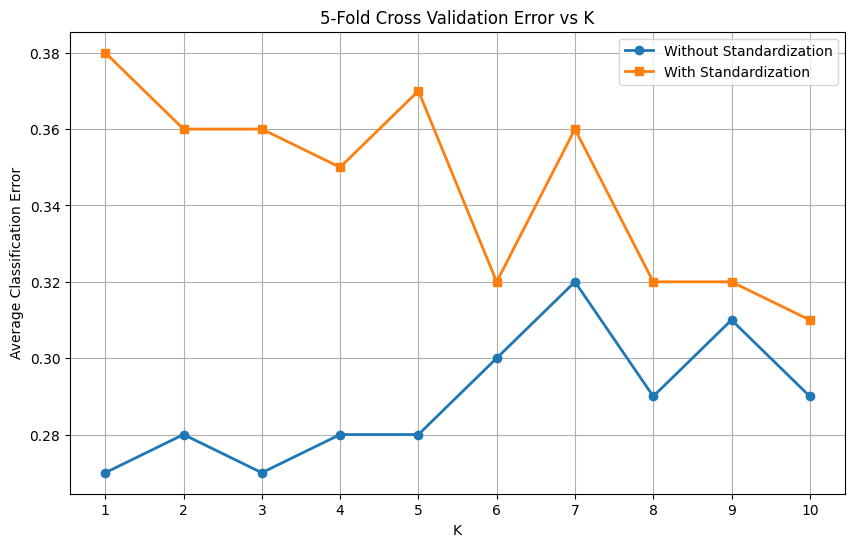

In [20]:
plt.figure(figsize=(10, 6))

plt.plot(
    k_raw,
    error_raw,
    marker='o',
    linewidth=2,
    label='Without Standardization'
)

plt.plot(
    k_scaled,
    error_scaled,
    marker='s',
    linewidth=2,
    label='With Standardization'
)

plt.xlabel("K")
plt.ylabel("Average Classification Error")
plt.title("5-Fold Cross Validation Error vs K")
plt.xticks(range(1, 11))
plt.grid(True)
plt.legend()
plt.savefig('error_plot.png')
plt.show()

# **KNN WITH SKLEARN**


KNN USING SCIKIT-LEARN

WITHOUT STANDARDIZATION
K =  1 | Error = 0.2600
K =  2 | Error = 0.2800
K =  3 | Error = 0.2700
K =  4 | Error = 0.2800
K =  5 | Error = 0.2700
K =  6 | Error = 0.3000
K =  7 | Error = 0.3000
K =  8 | Error = 0.2900
K =  9 | Error = 0.3000
K = 10 | Error = 0.3100

WITH STANDARDIZATION
K =  1 | Error = 0.3600
K =  2 | Error = 0.3500
K =  3 | Error = 0.3100
K =  4 | Error = 0.3600
K =  5 | Error = 0.3700
K =  6 | Error = 0.3700


c:\Users\Lenovo\anaconda3\envs\pytorch210\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\Lenovo\anaconda3\envs\pytorch210\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\Lenovo\anaconda3\envs\pytorch210\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\Lenovo\anaconda3\envs\pytorch210\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\Lenovo\anaconda3\envs\pytorch210\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 2 me

K =  7 | Error = 0.3600
K =  8 | Error = 0.3700
K =  9 | Error = 0.3500
K = 10 | Error = 0.3300

FINAL RESULTS
Without Scaling --> Best K = 1 | Min Error = 0.2600
With Scaling    --> Best K = 3 | Min Error = 0.3100


c:\Users\Lenovo\anaconda3\envs\pytorch210\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\Lenovo\anaconda3\envs\pytorch210\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\Lenovo\anaconda3\envs\pytorch210\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


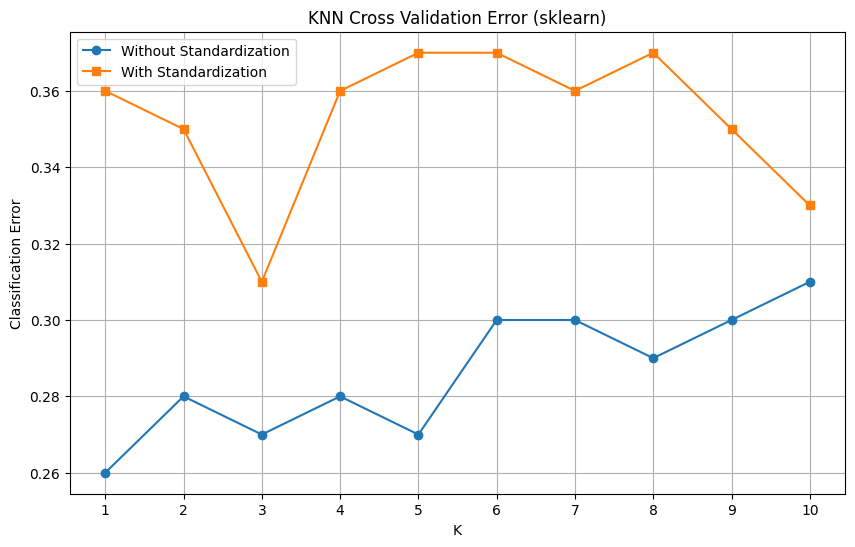

In [26]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


X = Data[:, :-1]
y = Data[:, -1]

# Cross Validation Setup (5-Fold)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

k_values = range(1, 11)

errors_raw = []
errors_scaled = []

print("\n" + "=" * 60)
print("KNN USING SCIKIT-LEARN")
print("=" * 60)

# WITHOUT STANDARDIZATION

print("\nWITHOUT STANDARDIZATION")

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    error = 1 - np.mean(scores)

    errors_raw.append(error)

    print(f"K = {k:2d} | Error = {error:.4f}")


# WITH STANDARDIZATION (Pipeline)

print("\nWITH STANDARDIZATION")

for k in k_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])

    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    error = 1 - np.mean(scores)

    errors_scaled.append(error)

    print(f"K = {k:2d} | Error = {error:.4f}")

# Best K

best_k_raw = k_values[np.argmin(errors_raw)]
best_k_scaled = k_values[np.argmin(errors_scaled)]

print("\n" + "=" * 60)
print("FINAL RESULTS")
print("=" * 60)

print(f"Without Scaling --> Best K = {best_k_raw} | Min Error = {min(errors_raw):.4f}")
print(f"With Scaling    --> Best K = {best_k_scaled} | Min Error = {min(errors_scaled):.4f}")

# Plot

plt.figure(figsize=(10, 6))

plt.plot(k_values, errors_raw, marker='o', label="Without Standardization")
plt.plot(k_values, errors_scaled, marker='s', label="With Standardization")

plt.title("KNN Cross Validation Error (sklearn)")
plt.xlabel("K")
plt.ylabel("Classification Error")
plt.xticks(k_values)
plt.grid(True)
plt.legend()
plt.savefig('sklearn_plot.png')

plt.show()